Reading the ARFF file into a data frame.

In [1]:
import os

import pandas as pd
import scipy as sc
import seaborn as sn
from matplotlib import pyplot as plt

In [2]:
file_path = os.path.abspath('../') + '/data/phpMawTba.arff'
assert os.path.exists(file_path)
arff_file = sc.io.arff.loadarff(file_path)
type(arff_file)

tuple

In [3]:
df = pd.DataFrame(arff_file[0])
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,b'Private',226802.0,b'11th',7.0,b'Never-married',b'Machine-op-inspct',b'Own-child',b'Black',b'Male',0.0,0.0,40.0,b'United-States',b'<=50K'
1,38.0,b'Private',89814.0,b'HS-grad',9.0,b'Married-civ-spouse',b'Farming-fishing',b'Husband',b'White',b'Male',0.0,0.0,50.0,b'United-States',b'<=50K'
2,28.0,b'Local-gov',336951.0,b'Assoc-acdm',12.0,b'Married-civ-spouse',b'Protective-serv',b'Husband',b'White',b'Male',0.0,0.0,40.0,b'United-States',b'>50K'
3,44.0,b'Private',160323.0,b'Some-college',10.0,b'Married-civ-spouse',b'Machine-op-inspct',b'Husband',b'Black',b'Male',7688.0,0.0,40.0,b'United-States',b'>50K'
4,18.0,b'?',103497.0,b'Some-college',10.0,b'Never-married',b'?',b'Own-child',b'White',b'Female',0.0,0.0,30.0,b'United-States',b'<=50K'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,b'Private',257302.0,b'Assoc-acdm',12.0,b'Married-civ-spouse',b'Tech-support',b'Wife',b'White',b'Female',0.0,0.0,38.0,b'United-States',b'<=50K'
48838,40.0,b'Private',154374.0,b'HS-grad',9.0,b'Married-civ-spouse',b'Machine-op-inspct',b'Husband',b'White',b'Male',0.0,0.0,40.0,b'United-States',b'>50K'
48839,58.0,b'Private',151910.0,b'HS-grad',9.0,b'Widowed',b'Adm-clerical',b'Unmarried',b'White',b'Female',0.0,0.0,40.0,b'United-States',b'<=50K'
48840,22.0,b'Private',201490.0,b'HS-grad',9.0,b'Never-married',b'Adm-clerical',b'Own-child',b'White',b'Male',0.0,0.0,20.0,b'United-States',b'<=50K'


In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

In [5]:
desc_dataset = arff_file[1]
print(f'Metadata =============================================\n {desc_dataset}')

Metadata =============================================
 Dataset: adult
	age's type is numeric
	workclass's type is nominal, range is ('Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Federal-gov', 'Local-gov', 'State-gov', 'Without-pay', 'Never-worked')
	fnlwgt's type is numeric
	education's type is nominal, range is ('Bachelors', 'Some-college', '11th', 'HS-grad', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', '9th', '7th-8th', '12th', 'Masters', '1st-4th', '10th', 'Doctorate', '5th-6th', 'Preschool')
	education-num's type is numeric
	marital-status's type is nominal, range is ('Married-civ-spouse', 'Divorced', 'Never-married', 'Separated', 'Widowed', 'Married-spouse-absent', 'Married-AF-spouse')
	occupation's type is nominal, range is ('Tech-support', 'Craft-repair', 'Other-service', 'Sales', 'Exec-managerial', 'Prof-specialty', 'Handlers-cleaners', 'Machine-op-inspct', 'Adm-clerical', 'Farming-fishing', 'Transport-moving', 'Priv-house-serv', 'Protective-serv', 'Armed-Forces')
	relationshi

In [6]:
typesDf = df.dtypes
features = sorted(typesDf.index)
features.remove('fnlwgt')
featuresdf = df.loc[:, features]
featuresdf.drop(columns=['class'], inplace=True)
featuresdf

,age,capital-gain,capital-loss,education,education-num,hours-per-week,marital-status,native-country,occupation,race,relationship,sex,workclass
0,25.0,0.0,0.0,b'11th',7.0,40.0,b'Never-married',b'United-States',b'Machine-op-inspct',b'Black',b'Own-child',b'Male',b'Private'
1,38.0,0.0,0.0,b'HS-grad',9.0,50.0,b'Married-civ-spouse',b'United-States',b'Farming-fishing',b'White',b'Husband',b'Male',b'Private'
2,28.0,0.0,0.0,b'Assoc-acdm',12.0,40.0,b'Married-civ-spouse',b'United-States',b'Protective-serv',b'White',b'Husband',b'Male',b'Local-gov'
3,44.0,7688.0,0.0,b'Some-college',10.0,40.0,b'Married-civ-spouse',b'United-States',b'Machine-op-inspct',b'Black',b'Husband',b'Male',b'Private'
4,18.0,0.0,0.0,b'Some-college',10.0,30.0,b'Never-married',b'United-States',b'?',b'White',b'Own-child',b'Female',b'?'
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,0.0,0.0,b'Assoc-acdm',12.0,38.0,b'Married-civ-spouse',b'United-States',b'Tech-support',b'White',b'Wife',b'Female',b'Private'
48838,40.0,0.0,0.0,b'HS-grad',9.0,40.0,b'Married-civ-spouse',b'United-States',b'Machine-op-inspct',b'White',b'Husband',b'Male',b'Private'
48839,58.0,0.0,0.0,b'HS-grad',9.0,40.0,b'Widowed',b'United-States',b'Adm-clerical',b'White',b'Unmarried',b'Female',b'Private'
48840,22.0,0.0,0.0,b'HS-grad',9.0,20.0,b'Never-married',b'United-States',b'Adm-clerical',b'White',b'Own-child',b'Male',b'Private'


In [7]:
target = "class"
targetSeries = df[target]
targetSeries.value_counts()


class
b'<=50K'    37155
b'>50K'     11687
Name: count, dtype: int64

In [8]:
print(f'all observations = {df.shape[0]}, all variables = {df.shape[1]}')
rowsdf, colsdf = featuresdf.shape
print(f'observations = {rowsdf}, features = {colsdf}')
print(targetSeries.shape)
print(f'target observations = {targetSeries.shape[0]}')

all observations = 48842, all variables = 15
observations = 48842, features = 13
(48842,)
target observations = 48842


For numeric type features:

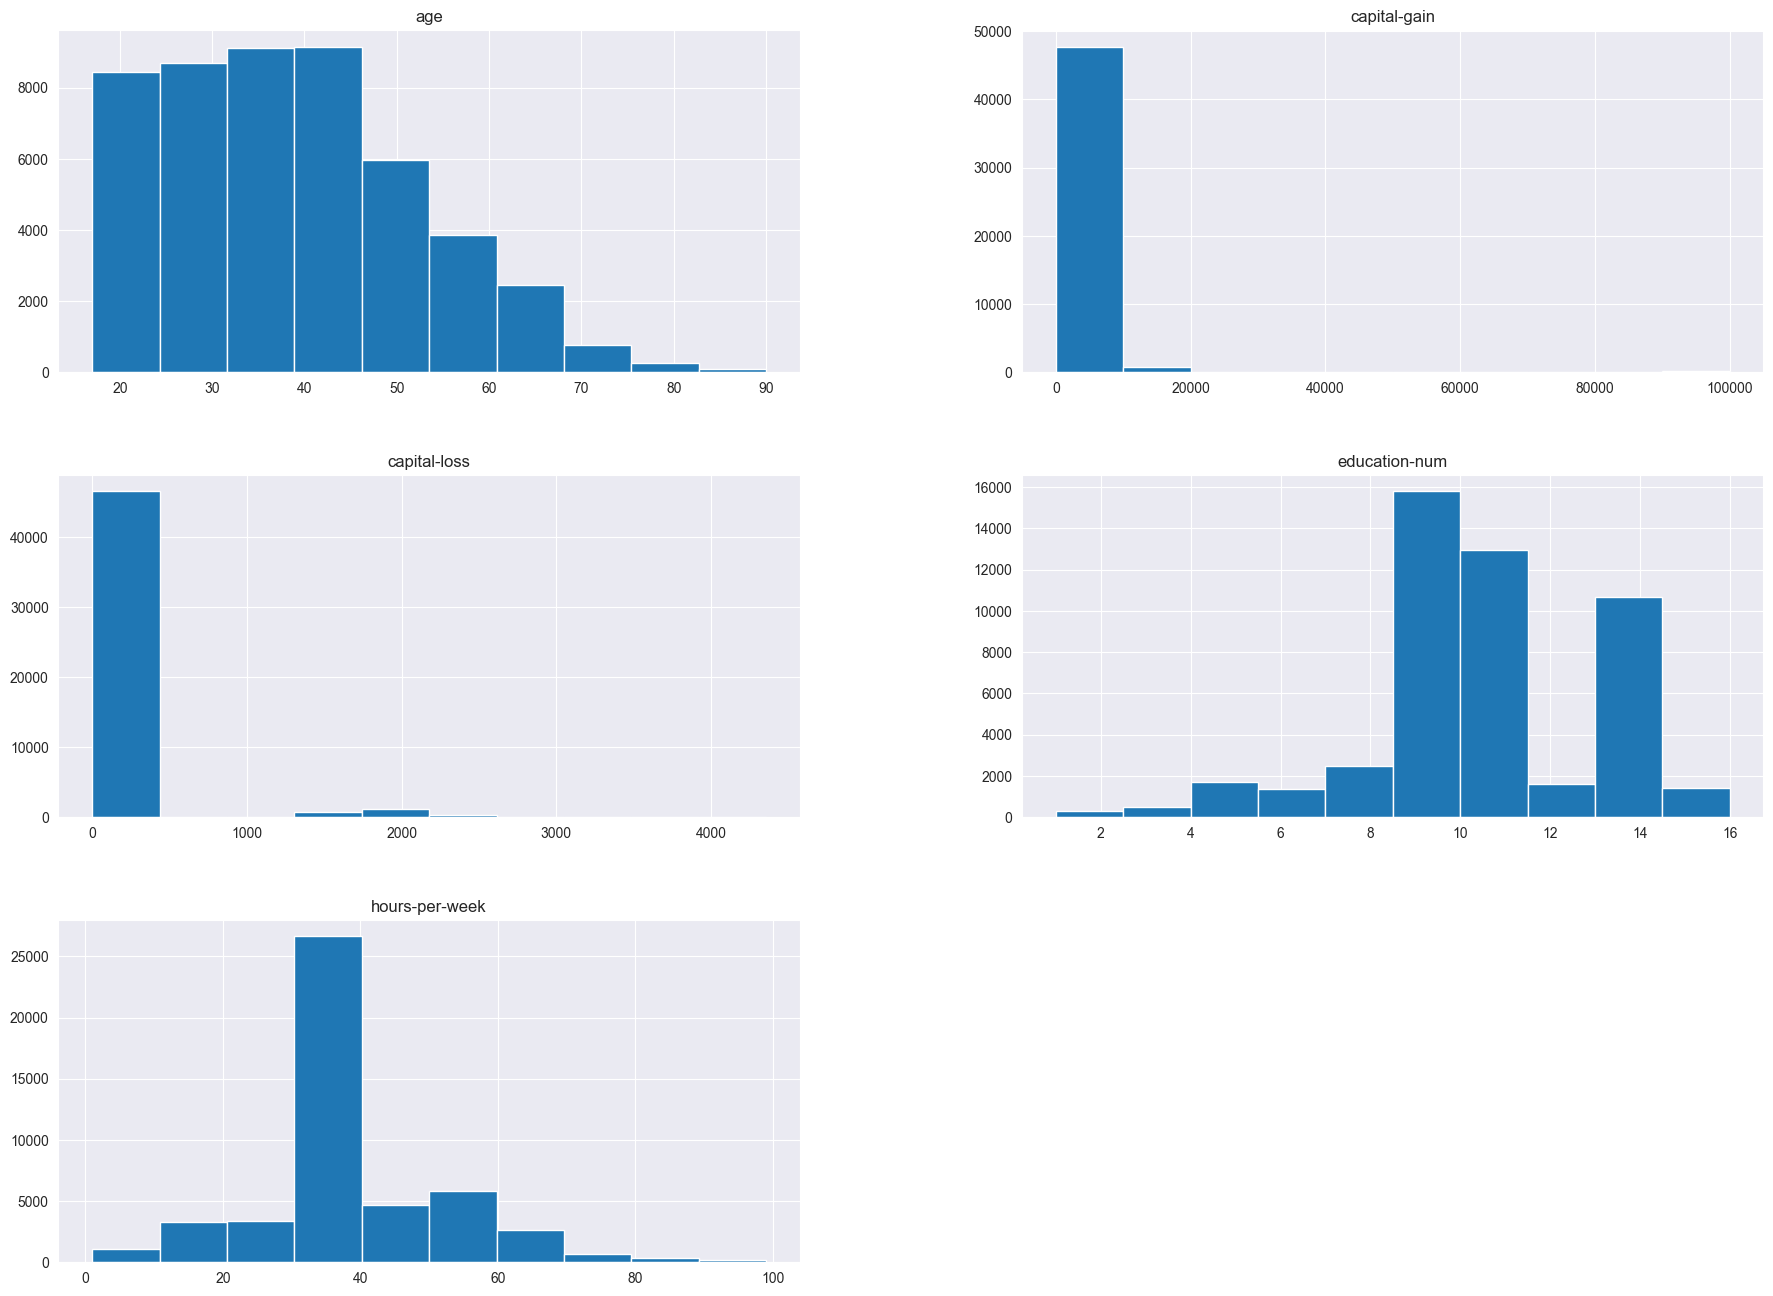

In [9]:
_ = featuresdf.hist(figsize=(22, 16))

In [10]:
featuresdf.loc[:, "sex"].value_counts()

sex
b'Male'      32650
b'Female'    16192
Name: count, dtype: int64

Two features with similar explanatory power.

In [11]:
featuresdf.loc[:, ["education", 'education-num']]

,education,education-num
0,b'11th',7.0
1,b'HS-grad',9.0
2,b'Assoc-acdm',12.0
3,b'Some-college',10.0
4,b'Some-college',10.0
...,...,...
48837,b'Assoc-acdm',12.0
48838,b'HS-grad',9.0
48839,b'HS-grad',9.0
48840,b'HS-grad',9.0


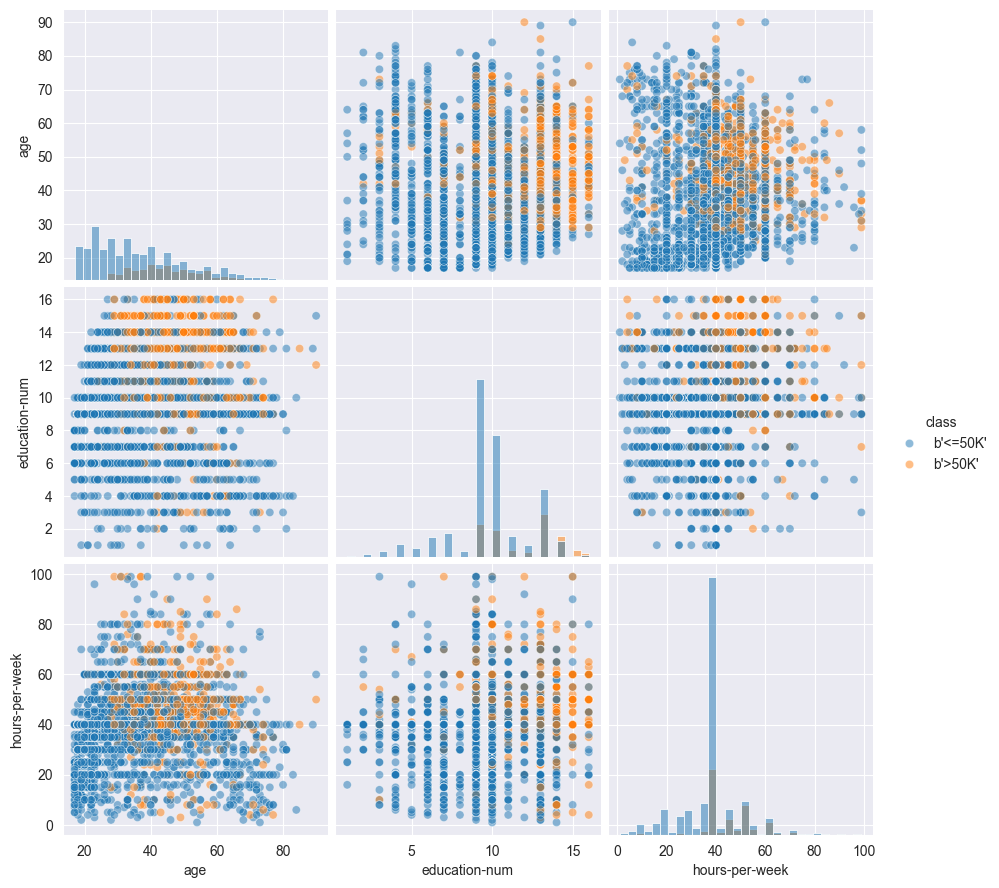

In [12]:
sample_plot = 5000
cols_plot = ['age', 'education-num', 'hours-per-week']
_ = sn.pairplot(data=df[:sample_plot], vars=cols_plot, hue=target, height=3, plot_kws={"alpha": 0.5}, diag_kind="hist",
                diag_kws={"bins": 30})

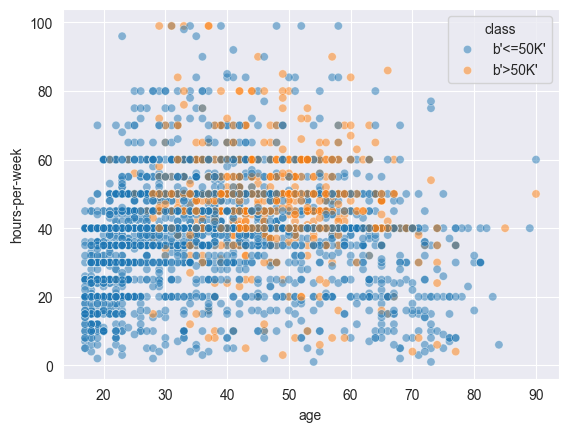

In [13]:
_ = sn.scatterplot(x="age", y="hours-per-week", data=df[:sample_plot], hue=target, alpha=0.5)

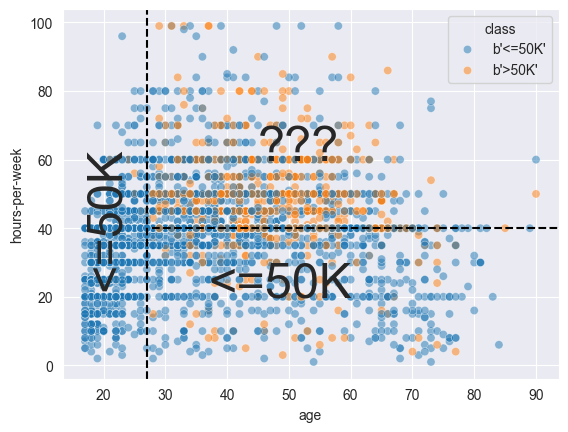

In [14]:
ax = sn.scatterplot(x="age", y="hours-per-week", data=df[:sample_plot], hue=target, alpha=0.5)

age_limit = 27
plt.axvline(x=age_limit, ymin=0, ymax=1, color="black", linestyle="--")

hours_per_week_limit = 40
plt.axhline(
    y=hours_per_week_limit, xmin=0.18, xmax=1, color="black", linestyle="--"
)

plt.annotate("<=50K", (17, 25), rotation=90, fontsize=35)
plt.annotate("<=50K", (37, 20), fontsize=35)
plt.annotate("???", (45, 60), fontsize=35);